# Demand Forecasting — End-to-End Machine Learning & Deep Learning Pipeline

**Dataset:** `demand_forecasting.csv` — 76,000 store-product-day observations covering **5 stores × 20 products × 760 daily dates** from **2022-01-01 to 2024-01-30**.

Each row represents one store-product-day and contains information about inventory, sales, ordering, pricing, promotions, competitor pricing, weather, seasonality, an epidemic indicator, and the target variable **`Demand`**.

## Project objective

The objective is to forecast daily demand for each store-product combination and compare four modelling approaches:

- **Linear Regression** — interpretable baseline
- **Random Forest** — non-linear ensemble model
- **XGBoost** — gradient-boosted tree model
- **LSTM** — recurrent deep-learning sequence model

The notebook follows an end-to-end forecasting workflow:

**Load → Inspect → Validate → Explore → Engineer features → Control leakage → Chronological split → Scale/encode → Train models → Evaluate → Interpret → Conclude**

## Business question

> **How accurately can future daily demand be predicted from historical demand patterns and available operational, commercial and contextual information, and which modelling approach provides the strongest forecasting performance?**

## Two decisions made before modelling

### 1. This is a regression forecasting problem

`Demand` is a continuous numerical target. Therefore, the appropriate evaluation measures are **MAE, RMSE, MAPE and R²**, supported by actual-vs-predicted and residual visualisations.

Classification measures such as accuracy, precision, recall, ROC-AUC and confusion matrices are not appropriate for the target used in this notebook.

### 2. Same-day leakage is explicitly controlled

`Units Sold` and same-day `Inventory Level` are available in the dataset, but their same-day values are not used directly as predictors.

The reason is practical: when forecasting demand for a future day, the realised sales and inventory outcome for that same day would not yet exist. Using those values would allow the model to use information that would only become known after the demand event.

Historical versions are still used through lag and rolling features.

> **Forecasting principle:** A predictor should only be included if it would genuinely be available at the time the forecast is generated.

## Portfolio focus

This project is intentionally structured to show the full modelling decision process. A more complex model is not automatically treated as better. The final model is selected from the observed test-set performance and the characteristics of the forecasting problem.

## 1. Setup & Imports

The first section installs and imports the libraries required for the analysis.

The notebook uses:

- **pandas / NumPy** for data manipulation
- **Matplotlib / Seaborn** for visualisation
- **scikit-learn** for classical machine-learning models and preprocessing
- **XGBoost** for gradient boosting
- **TensorFlow / Keras** for the LSTM model
- **skimpy** for a compact dataset summary

A fixed random seed is used where supported so that model results are as reproducible as possible.

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install plotnine
!pip install great_tables
!pip install skimpy
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.4/495.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.1 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's depe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimpy import skim

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


### Setup conclusion

The modelling environment is now ready for both tabular machine learning and deep learning.

Because the notebook is intended for portfolio use, the imports are kept explicit so that a reader can see which technologies are actually used rather than relying on hidden dependencies.

## 2. Load the Dataset

The dataset is loaded directly from the Colab working directory and `Date` is parsed as a datetime field.

Parsing the date at this stage is important because the notebook later uses it to:

- establish the chronological range,
- create calendar features,
- sort observations within each store-product series,
- and create a time-based train/test split.

No synthetic data is generated; the analysis uses the supplied `demand_forecasting.csv` file.

In [ ]:
df_raw = pd.read_csv('/content/demand_forecasting.csv', parse_dates=['Date'])   # load the real dataset directly
print(f"Loaded — shape: {df_raw.shape}")


Loaded — shape: (76000, 16)


### Dataset loading result

The dataset contains **76,000 rows and 16 columns**.

This is consistent with the expected panel structure:

**5 stores × 20 products × 760 daily dates = 76,000 observations.**

The full row count is therefore an important first validation that the dataset represents a complete store-product-day panel.

## 3. Display & Inspect the Dataset

Before cleaning or modelling, the notebook inspects the dataset's dimensions, data types, first observations, descriptive statistics and time-series coverage.

This establishes what each variable looks like and helps identify potential issues before feature engineering begins.

In [ ]:
print("Shape:", df_raw.shape)
print()
print(df_raw.dtypes)
print()
df_raw.head(10)


Shape: (76000, 16)

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object



,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


In [ ]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,76000,NaN,NaN,NaN,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Store ID,76000,5,S001,15200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,76000,20,P0001,3800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,76000,5,Groceries,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,76000,4,North,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,76000.0,NaN,NaN,NaN,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,NaN,NaN,NaN,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,NaN,NaN,NaN,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,NaN,NaN,NaN,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,NaN,NaN,NaN,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781


In [ ]:
print("Date range:", df_raw['Date'].min(), "to", df_raw['Date'].max())
print("Unique dates:", df_raw['Date'].nunique())
print("Unique stores:", df_raw['Store ID'].nunique())
print("Unique products:", df_raw['Product ID'].nunique())
print("Store x Product x Date =", df_raw['Store ID'].nunique() * df_raw['Product ID'].nunique() * df_raw['Date'].nunique())
print("Actual row count:", len(df_raw), "-- confirms this is a complete panel, no missing store/product/day combinations")


Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Unique dates: 760
Unique stores: 5
Unique products: 20
Store x Product x Date = 76000
Actual row count: 76000 -- confirms this is a complete panel, no missing store/product/day combinations


### Dataset structure conclusion

The dataset covers **760 consecutive dates**, **5 stores** and **20 products**, creating **100 store-product time series**.

The target, `Demand`, is numeric, confirming that the task is a regression problem.

The panel structure is particularly important: historical features must be calculated within each Store-Product combination so that one series' history never becomes another series' lag.

## 4. Data Quality & Time-Series Structure

Forecasting requires more than checking for missing values and duplicates. The notebook also verifies that every Store-Product combination has a complete daily sequence.

This matters because the later lag and rolling-window features assume that observations are correctly ordered and that a seven-day lag actually represents seven calendar days of history.

The checks cover:

1. Missing values
2. Duplicate rows
3. Number of Store-Product combinations
4. Number of observations in each series
5. Chronological ordering

In [ ]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())


Missing values per column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

Duplicate rows: 0


In [ ]:
# Confirm every Store-Product pair has exactly one row per date (no gaps, no duplicates within a group)
counts = df_raw.groupby(['Store ID', 'Product ID'])['Date'].count()
print(f"Store-Product combinations: {len(counts)}")
print(f"All have exactly {counts.iloc[0]} rows: {(counts == counts.iloc[0]).all()}")

df = df_raw.sort_values(['Store ID', 'Product ID', 'Date']).reset_index(drop=True)


Store-Product combinations: 100
All have exactly 760 rows: True


### Data-quality findings

The dataset passes the main structural checks:

- **0 missing values**
- **0 duplicate rows**
- **100 Store-Product combinations**
- **760 observations in every Store-Product series**

The expected panel size is therefore fully represented.

This is a strong foundation for lag and rolling features because the time series are complete and gapless at the Store-Product level.

## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the demand process before modelling.

The analysis starts with a compact statistical summary and then examines:

- overall demand over time,
- calendar seasonality,
- weather and promotion,
- epidemic and seasonal conditions,
- differences between stores and categories,
- and relationships among numerical variables.

The purpose is not to prove causality. Instead, EDA identifies patterns that may contain useful predictive information and helps justify the feature-engineering decisions used later.

In [ ]:
skim(df)


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 76000  │ │ int64       │ 7     │                                                          │
│ │ Number of columns │ 16     │ │ string      │ 6     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 2     │                                                          │
│                                │ datetime64  │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0    ┃ p25    ┃ p50   ┃ p75    ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Inventory Level       │   0 │     0 │   301.1 │   226.5 │     0 │    136 │   227 │    408 │  2267 │   █▃   │  │
│ │ Units Sold            │   0 │     0 │   88.83 │   43.99 │     0 │     58 │    84 │    114 │   426 │  ▆█▂   │  │
│ │ Units Ordered         │   0 │     0 │   89.09 │   162.4 │     0 │      0 │     0 │    121 │  1616 │   █▁   │  │
│ │ Price                 │   0 │     0 │   67.73 │   39.38 │  4.74 │     32 │  64.5 │  95.83 │   228 │ █▇▆▃▁  │  │
│ │ Discount              │   0 │     0 │   9.087 │   7.476 │     0 │      5 │    10 │     10 │    25 │ ▆▆█▂▂▂ │  │
│ │ Promotion             │   0 │     0 │  0.3289 │  0.4698 │     0 │      0 │     0 │      1 │     1 │ █    ▄ │  │
│ │ Competitor Pricing    │   0 │     0 │   69.45 │   40.94 │  4.29 │  32.62 │  65.7 │  97.93 │ 261.2 │  ██▅▂  │  │
│ │ Epidemic              │   0 │     0 │     0.2 │     0.4 │     0 │      0 │     0 │      0 │     1 │ █    ▂ │  │
│ │ Demand                │   0 │     0 │   104.3 │   46.96 │     4 │     71 │   100 │    133 │   430 │  ▄█▂   │  │
│ └───────────────────────┴─────┴───────┴─────────┴─────────┴───────┴────────┴───────┴────────┴───────┴────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA     ┃ NA %       ┃ first                 ┃ last                  ┃ frequency           ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Date           │      0 │          0 │      2022-01-01       │      2024-01-30       │ None                │  │
│ └────────────────┴────────┴────────────┴───────────────────────┴───────────────────────┴─────────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃            ┃    ┃      ┃          ┃            ┃          ┃        ┃ chars per  ┃ words per   ┃ total      ┃  │
│ ┃ column     ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min      ┃ max    ┃ row        ┃ row         ┃ words      ┃  │
│ ┡━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━

### Figure 1 — Total Daily Demand Across All Stores and Products

This line chart aggregates demand across the entire retail panel for each date.

**What the graph is checking:**
- long-term demand movement,
- repeated peaks and troughs,
- possible seasonality,
- unusual periods or spikes.

The aggregation provides a high-level view of the demand environment. However, it can hide differences between individual stores and products, so the later group-level analysis remains important.

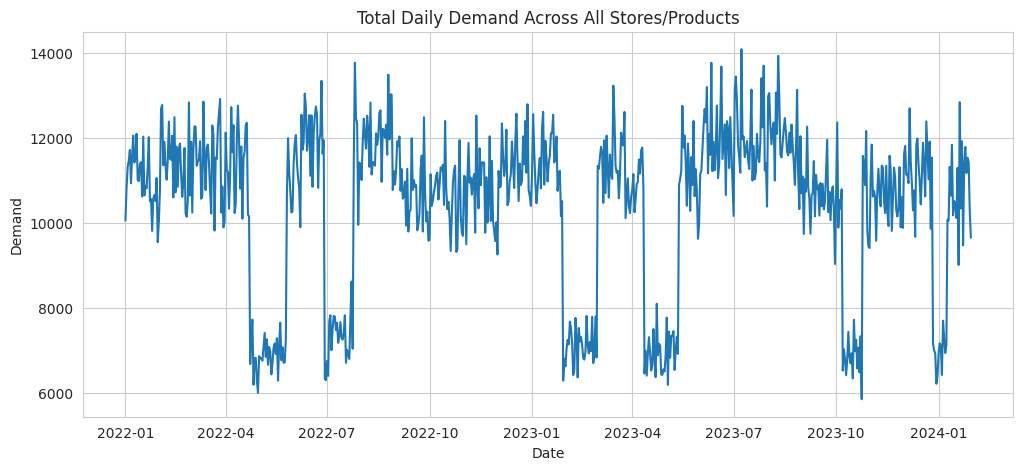

In [ ]:
# Overall demand trend (summed across all stores/products per day)
daily = df.groupby('Date')['Demand'].sum().reset_index()

plt.plot(daily['Date'], daily['Demand'])
plt.title('Total Daily Demand Across All Stores/Products')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()


### Figure 1 interpretation

The aggregate demand series provides the first indication of how demand behaves through time.

Any repeating or systematic movement supports the use of historical and calendar-based features. More importantly, the chart demonstrates why this problem should be treated as a time-series forecasting task rather than as a standard randomly sampled regression problem.

### Figure 2 — Demand by Day of Week and Month

These boxplots examine whether demand distributions differ across calendar periods.

- The **day-of-week** view checks for weekly patterns.
- The **month** view checks for broader calendar variation.

The plots operate at the store-product-row level rather than summing the entire dataset, so they show how individual demand observations are distributed across calendar groups.

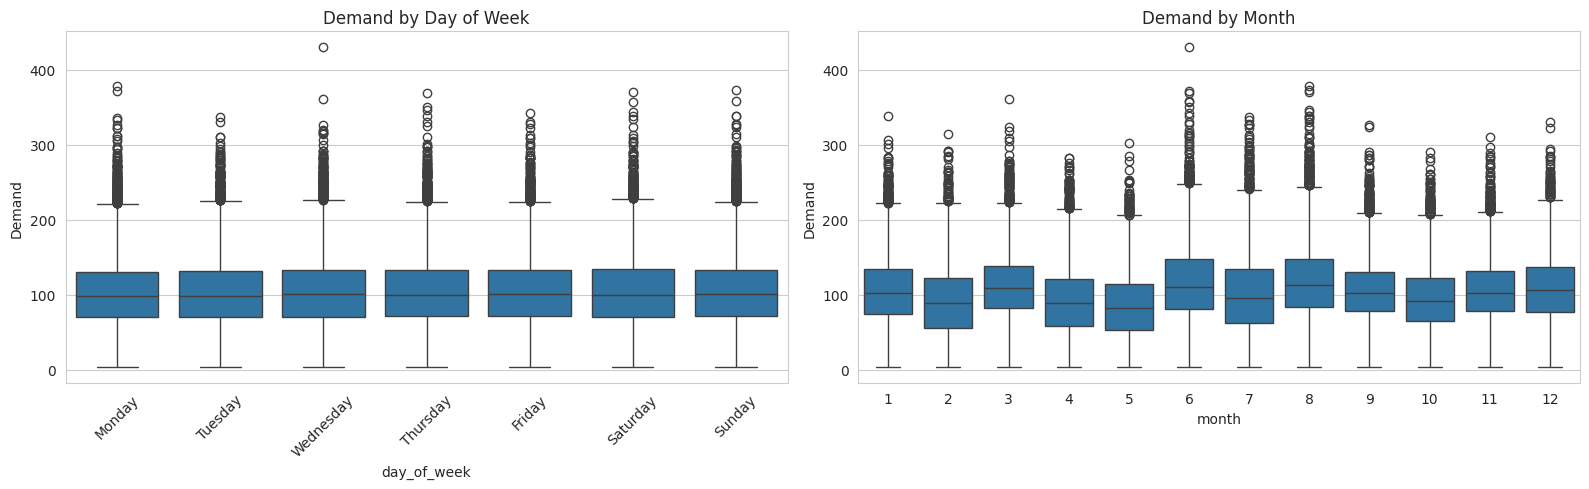

In [ ]:
# Seasonality: day-of-week and month effects, at the per-row level (not summed)
df['day_of_week'] = df['Date'].dt.day_name()
df['month'] = df['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(data=df, x='day_of_week', y='Demand', order=order, ax=axes[0])
axes[0].set_title('Demand by Day of Week')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='month', y='Demand', ax=axes[1])
axes[1].set_title('Demand by Month')

plt.tight_layout()
plt.show()


### Figure 2 interpretation

Differences across weekdays and months provide evidence that calendar information may improve forecasts.

This motivates creating explicit calendar features such as day-of-week, quarter and weekend indicators. These variables give the models access to recurring calendar structure rather than requiring the model to infer all of it indirectly from the date itself.

### Figure 3 — Demand by Weather, Promotion, Epidemic and Seasonality

This four-panel visual compares demand distributions across contextual conditions.

These variables are considered potential **exogenous predictors** because they provide information beyond the historical demand series.

The comparisons are descriptive: a difference between groups indicates an association in the dataset, not proof that the factor independently causes demand to change.

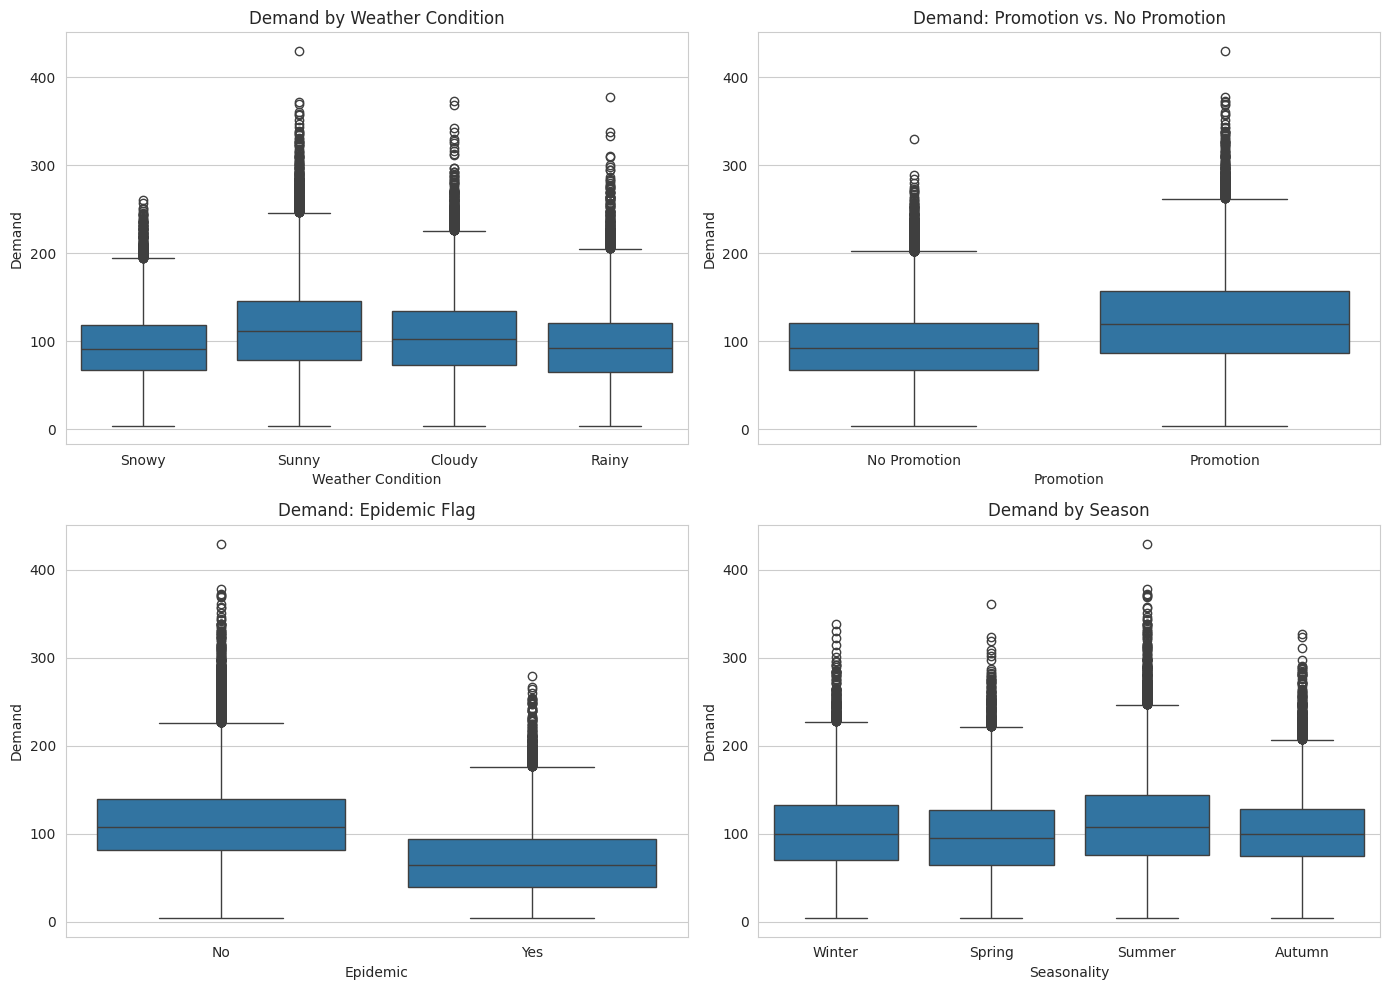

In [ ]:
# Categorical drivers: weather, promotion, epidemic, seasonality
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Weather Condition', y='Demand', ax=axes[0,0])
axes[0,0].set_title('Demand by Weather Condition')

sns.boxplot(data=df, x='Promotion', y='Demand', ax=axes[0,1])
axes[0,1].set_title('Demand: Promotion vs. No Promotion')
axes[0,1].set_xticklabels(['No Promotion', 'Promotion'])

sns.boxplot(data=df, x='Epidemic', y='Demand', ax=axes[1,0])
axes[1,0].set_title('Demand: Epidemic Flag')
axes[1,0].set_xticklabels(['No', 'Yes'])

sns.boxplot(data=df, x='Seasonality', y='Demand', ax=axes[1,1])
axes[1,1].set_title('Demand by Season')

plt.tight_layout()
plt.show()


### Figure 3 interpretation

The contextual variables show that demand can differ depending on operational and environmental conditions.

Promotion and seasonal information are particularly relevant from a forecasting perspective because they may be known or planned before a forecast is generated.

Weather requires more careful interpretation. In this notebook the variable is treated as available contextual information, but a production forecasting system would normally use a **weather forecast** rather than the realised weather condition for the target day.

### Figure 4 — Demand by Store and Product Category

These boxplots examine structural differences between stores and product categories.

This matters because a forecasting model needs to distinguish between naturally higher- and lower-demand series. Store and product identity can therefore provide information that is not contained in the historical demand value alone.

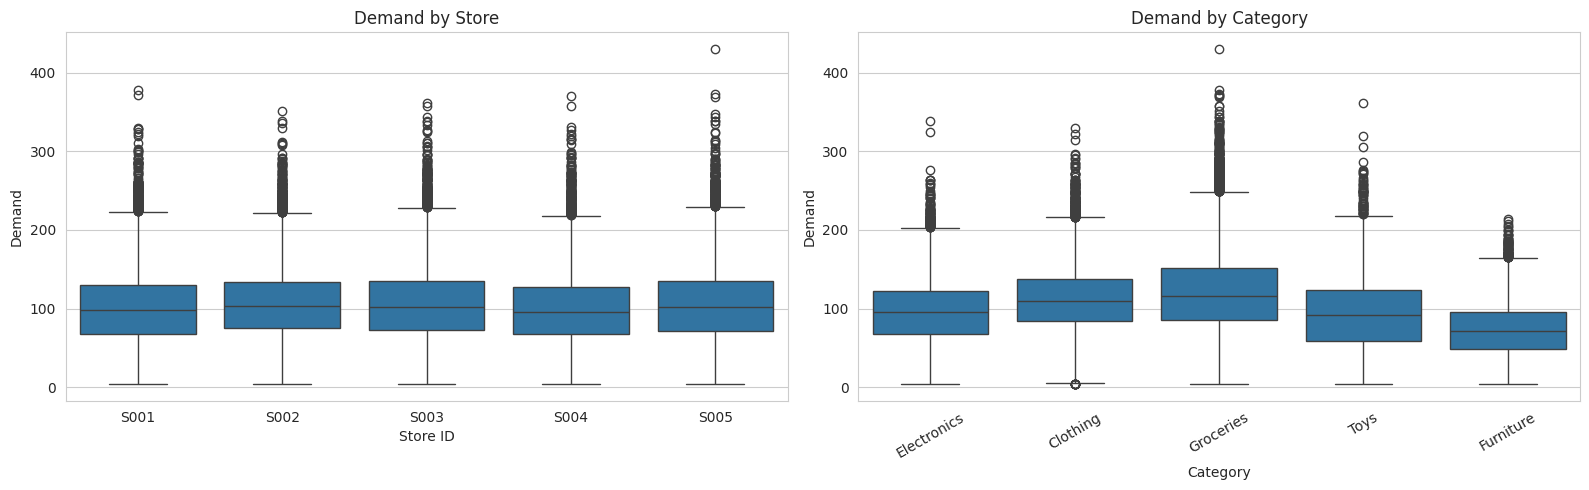

In [ ]:
# Demand by store and by category — checking for structural differences between groups,
# since the models below will need to generalize across all of them
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='Store ID', y='Demand', ax=axes[0])
axes[0].set_title('Demand by Store')

sns.boxplot(data=df, x='Category', y='Demand', ax=axes[1])
axes[1].set_title('Demand by Category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### Figure 4 interpretation

The distributional differences between stores and categories support the inclusion of store/product and category information in the tabular models.

They also reinforce the importance of modelling the data as a panel rather than assuming that every store-product combination follows one identical demand pattern.

### Figure 5 — Correlation Matrix of Numerical Variables

The correlation matrix provides a diagnostic view of linear relationships between numerical variables.

`Units Sold` and `Inventory Level` are included here for **context**, but their same-day values are not used as direct predictors later because of the forecasting-time leakage decision described in the introduction.

This distinction is important:

> A variable can be statistically useful while still being invalid for a real forecasting scenario if it is only known after the target event occurs.

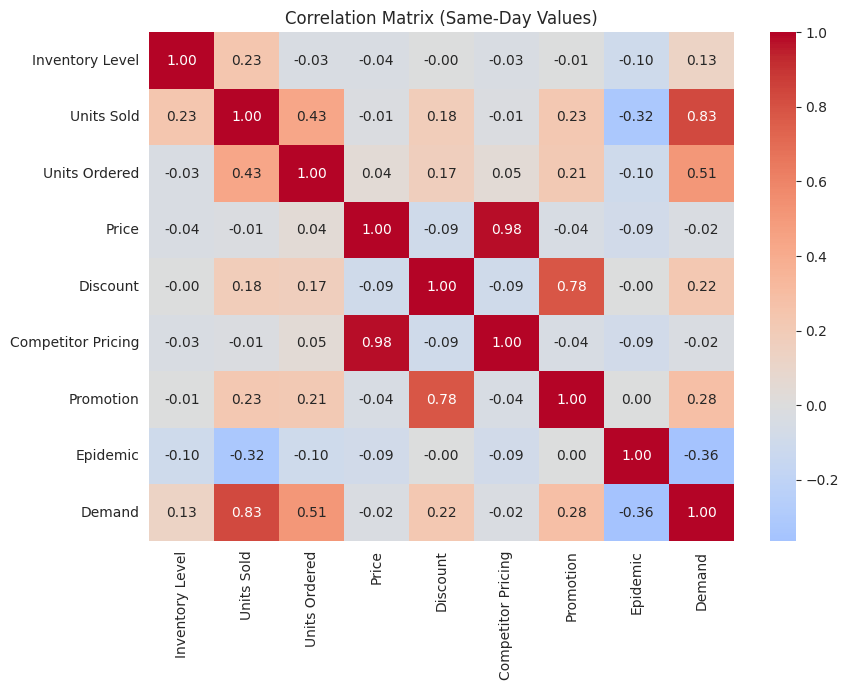

In [ ]:
# Correlation among the numeric columns, including Units Sold/Inventory Level for context —
# shown here for completeness even though (per the leakage note above) same-day versions of
# these are excluded from the actual feature set below.
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
                 'Competitor Pricing', 'Promotion', 'Epidemic', 'Demand']
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Same-Day Values)')
plt.tight_layout()
plt.show()


### Figure 5 interpretation

The correlation analysis helps identify which variables contain strong relationships with demand and which predictors may overlap with one another.

The particularly strong relationship between same-day `Units Sold` and `Demand` illustrates why leakage control matters. A model could appear extremely accurate if it were allowed to use a near-outcome variable that would not exist at prediction time.

The final feature set therefore uses **historical lags and rolling statistics** rather than the same-day realised sales outcome.

### EDA Takeaways

The exploratory analysis establishes the main characteristics of the forecasting problem:

- Demand varies through time, supporting lag and calendar features.
- Demand differs across stores and product categories.
- Promotion, weather, seasonality and epidemic status provide potentially useful contextual information.
- Same-day operational outcomes are highly informative but must be treated carefully to avoid leakage.
- The complete Store-Product panel makes group-specific historical feature engineering reliable.

These findings directly inform the preparation and modelling strategy in the next section.

## 6. Feature Engineering & Data Preparation

Feature engineering converts the raw retail data into variables that better represent the information available when a future demand forecast is generated.

The feature set is divided into four groups:

### 6.1 Calendar features
- Day of week
- Month
- Quarter
- Weekend indicator

### 6.2 Historical demand and operational features

Lag and rolling features are calculated **within each Store-Product series** for:

- `Demand`
- `Units Sold`
- `Inventory Level`

The notebook uses historical values such as:

- 1-day lag
- 7-day lag
- 7-day rolling mean
- 14-day rolling mean

Rolling statistics are shifted so that the current target day's outcome cannot enter its own predictor.

### 6.3 Contextual features

The models retain information such as:

- Price
- Discount
- Promotion
- Competitor Pricing
- Weather Condition
- Seasonality
- Epidemic

These variables are treated as available contextual information under the assumptions of this dataset.

### 6.4 Categorical encoding

Categorical variables are one-hot encoded for the classical tabular models.

### Why group-specific lags matter

A lag must refer to the **same Store-Product series**. For example, the seven-day demand history for Store A / Product 1 should never accidentally use the demand from Store B / Product 1.

This is why the feature engineering is performed after sorting and within Store-Product groups.

In [ ]:
df_feat = df.copy()

# Date features
df_feat['day_of_week_num'] = df_feat['Date'].dt.dayofweek
df_feat['quarter'] = df_feat['Date'].dt.quarter
df_feat['is_weekend'] = (df_feat['day_of_week_num'] >= 5).astype(int)
df_feat['year'] = df_feat['Date'].dt.year


In [ ]:
# Lag and rolling features, computed per Store-Product group using .transform() rather than
# .groupby().apply() -- as of pandas 3.0, groupby-apply always drops the grouping columns from
# the result (a real breaking change from earlier pandas versions), so .transform() is used
# here instead: it's also the more idiomatic tool for this since it returns a same-shaped
# Series aligned to the original index, without needing to reconstruct the group keys after.
group_key = ['Store ID', 'Product ID']

for col in ['Demand', 'Units Sold', 'Inventory Level']:
    df_feat[f'{col}_lag_1'] = df_feat.groupby(group_key)[col].shift(1)
    df_feat[f'{col}_lag_7'] = df_feat.groupby(group_key)[col].shift(7)
    df_feat[f'{col}_rolling_mean_7'] = df_feat.groupby(group_key)[col].transform(
        lambda s: s.shift(1).rolling(7).mean()
    )
    df_feat[f'{col}_rolling_mean_14'] = df_feat.groupby(group_key)[col].transform(
        lambda s: s.shift(1).rolling(14).mean()
    )

# Drop rows where lag/rolling features couldn't be computed (first 14 days of each series)
before = len(df_feat)
df_feat = df_feat.dropna(subset=[c for c in df_feat.columns if 'lag' in c or 'rolling' in c])
print(f"Dropped {before - len(df_feat):,} rows with insufficient history "
      f"(first 14 days of each of the {df['Store ID'].nunique() * df['Product ID'].nunique()} series)")
print("Shape after feature engineering:", df_feat.shape)


Dropped 1,400 rows with insufficient history (first 14 days of each of the 100 series)
Shape after feature engineering: (74600, 34)


In [ ]:
categorical_cols = ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']
df_encoded = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)

# Same-day columns excluded per the leakage decision above -- only their lag/rolling versions remain
leaky_same_day_cols = ['Units Sold', 'Inventory Level', 'Units Ordered', 'day_of_week']
feature_cols = [c for c in df_encoded.columns
                if c not in leaky_same_day_cols + ['Date', 'Demand']]

print(f"Final feature count: {len(feature_cols)}")


Final feature count: 58


### Feature-engineering conclusion

The raw dataset is transformed into a modelling table containing explicit historical demand signals, operational history, calendar effects and contextual variables.

The first observations of each Store-Product series cannot have a complete lag/rolling history, so those rows are naturally removed during feature creation.

The resulting features provide the tabular models with much of the temporal structure they need without exposing same-day realised outcomes.

### 6.5 Chronological Train/Test Split

The dataset is split according to time rather than randomly.

The most recent approximately **20% of dates** are reserved for testing.

This mirrors the real forecasting scenario:

> **Train on the past → predict the future.**

A random split would allow observations from later dates to enter the training data and could produce an overly optimistic estimate of future forecasting performance.

The chronological split is therefore a core part of the methodology rather than simply a technical preference.

In [ ]:
split_date = df_encoded['Date'].quantile(0.8, interpolation='nearest')

train = df_encoded[df_encoded['Date'] <= split_date]
test = df_encoded[df_encoded['Date'] > split_date]

X_train, y_train = train[feature_cols], train['Demand']
X_test, y_test = test[feature_cols], test['Demand']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train period: {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"Test period:  {test['Date'].min().date()} to {test['Date'].max().date()}")


Train: (59700, 58), Test: (14900, 58)
Train period: 2022-01-15 to 2023-09-03
Test period:  2023-09-04 to 2024-01-30


### Train/test split result

The split creates:

- **59,700 training observations**
- **14,900 test observations**
- **58 predictors**

The test period begins on **2023-09-04** and ends on **2024-01-30**.

The model therefore receives historical observations during training and is evaluated on a later period that it did not see during fitting.

### 6.6 Feature Scaling

Standardisation is applied for the Linear Regression model and the LSTM sequence features.

The scaler is fitted using the training data only and then applied to the test data.

This prevents the mean and standard deviation of the future test period from influencing the training transformation.

Tree-based models such as Random Forest and XGBoost do not require the same feature scaling because their split decisions are not based on distance or coefficient magnitude in the same way.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete — used by Linear Regression and the LSTM; tree models use the unscaled versions.")


Scaling complete — used by Linear Regression and the LSTM; tree models use the unscaled versions.


## 7. Modelling — Classical Machine Learning & Deep Learning

Four models are compared to determine whether a simple linear relationship, tree-based ensemble, gradient boosting or recurrent neural network provides the strongest forecasting performance.

The models are intentionally diverse:

| Model | Role in the comparison |
|---|---|
| **Linear Regression** | Simple, interpretable baseline |
| **Random Forest** | Non-linear ensemble |
| **XGBoost** | Gradient-boosted tabular model |
| **LSTM** | Sequence-based deep-learning model |

The purpose is not to assume that one family is superior. The held-out test results determine which approach works best for this dataset and feature setup.

### 7.1 Linear Regression

Linear Regression provides the baseline.

It estimates demand as a linear combination of the engineered predictors. It is relatively easy to interpret and provides a useful reference point.

If a complex model only marginally improves on this baseline, the added complexity may not be justified.

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
print("Linear Regression trained.")


Linear Regression trained.


### Linear Regression conclusion

The Linear Regression model establishes the minimum performance benchmark against which the non-linear models and LSTM can be judged.

Its performance also provides a useful indication of how much of the demand variation can be captured using approximately linear relationships between the engineered predictors and the target.

### 7.2 Random Forest

Random Forest is introduced to capture non-linear relationships and interactions that Linear Regression cannot represent directly.

The model combines many decision trees, reducing dependence on any individual tree and allowing more flexible relationships between demand and the engineered features.

The model is trained on the unscaled tabular features because tree-based models do not require standardisation for their split-based learning process.

In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest trained.")


Random Forest trained.


### Random Forest conclusion

Random Forest provides a stronger non-linear benchmark than Linear Regression and tests whether interactions between historical demand, customer/store/product attributes and contextual variables improve forecasting accuracy.

### 7.3 XGBoost

XGBoost is a gradient-boosted tree model designed for structured/tabular data.

Instead of building independent trees, boosting builds trees sequentially so that later trees focus on reducing errors made by the previous ensemble.

This is particularly relevant here because the dataset contains a mixture of categorical information, numerical variables and carefully engineered lag/rolling features.

In [ ]:
xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                    random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
print("XGBoost trained.")


XGBoost trained.


### XGBoost conclusion

XGBoost is a strong candidate for this type of structured forecasting problem because it can model non-linear relationships and interactions while making effective use of the engineered historical features.

However, its final position in the model comparison is determined by the held-out test results rather than by the algorithm's reputation or complexity.

### 7.4 LSTM — Deep Learning

The LSTM provides a sequence-based alternative to the tabular models.

For each Store-Product series, the model receives a **14-day historical window** and predicts the following day's demand.

The architecture contains:

- LSTM layer with 64 units
- Dropout
- LSTM layer with 32 units
- Dropout
- Dense layer with 16 units
- Single continuous output

The LSTM is intentionally compact because the data contains 100 individual series with approximately 760 daily observations per series. A substantially larger network could increase training cost and overfitting risk.

The LSTM is not using raw demand alone: it receives a curated set of historical and contextual features at each timestep. Its key distinction is that it processes those observations as a **sequence**.

In [ ]:
LOOKBACK = 14

sequence_numeric_cols = [
    'Price', 'Discount', 'Competitor Pricing', 'Promotion', 'Epidemic',
    'day_of_week_num', 'quarter', 'is_weekend',
    'Demand_lag_1', 'Demand_lag_7', 'Demand_rolling_mean_7', 'Demand_rolling_mean_14',
    'Units Sold_lag_1', 'Units Sold_lag_7', 'Units Sold_rolling_mean_7', 'Units Sold_rolling_mean_14',
    'Inventory Level_lag_1', 'Inventory Level_lag_7',
    'Inventory Level_rolling_mean_7', 'Inventory Level_rolling_mean_14',
]

def build_sequences(frame, feature_cols, target_col, lookback):
    """Build (lookback x features) windows -> next-day target, per Store-Product group,
    never crossing a group boundary."""
    X_seq, y_seq, dates_seq = [], [], []
    for (store, product), g in frame.groupby(['Store ID', 'Product ID']):
        g = g.sort_values('Date')
        values = g[feature_cols].values
        targets = g[target_col].values
        dates = g['Date'].values
        for i in range(lookback, len(g)):
            X_seq.append(values[i - lookback:i])
            y_seq.append(targets[i])
            dates_seq.append(dates[i])
    return np.array(X_seq), np.array(y_seq), np.array(dates_seq)

# Built from df_feat (pre-dummy-encoding, still has Store ID/Product ID for grouping)
X_seq_all, y_seq_all, dates_seq_all = build_sequences(
    df_feat, sequence_numeric_cols, 'Demand', LOOKBACK
)
print(f"Built {len(X_seq_all):,} sequences of shape {X_seq_all.shape[1:]} (lookback x features)")


Built 73,200 sequences of shape (14, 20) (lookback x features)


In [ ]:
# Same time-based split boundary as the tabular models
seq_train_mask = dates_seq_all <= np.datetime64(split_date)
seq_test_mask = ~seq_train_mask

X_seq_train, y_seq_train = X_seq_all[seq_train_mask], y_seq_all[seq_train_mask]
X_seq_test, y_seq_test = X_seq_all[seq_test_mask], y_seq_all[seq_test_mask]

print(f"Sequence train: {X_seq_train.shape}, Sequence test: {X_seq_test.shape}")


Sequence train: (58300, 14, 20), Sequence test: (14900, 14, 20)


In [ ]:
# Scale sequence features -- fit only on the training sequences, applied to both.
# Reshaped to 2D for the scaler, then back to (samples, lookback, features) for the LSTM.
n_features_seq = X_seq_train.shape[2]

seq_scaler = StandardScaler()
X_seq_train_scaled = seq_scaler.fit_transform(
    X_seq_train.reshape(-1, n_features_seq)
).reshape(X_seq_train.shape)
X_seq_test_scaled = seq_scaler.transform(
    X_seq_test.reshape(-1, n_features_seq)
).reshape(X_seq_test.shape)


In [ ]:
# LSTM architecture: kept intentionally small -- ~75k sequences and 20 features per timestep
# don't need a deep/wide network, and an oversized model on data this size would mostly just
# overfit rather than learn anything a smaller one couldn't.
lstm_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, n_features_seq)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM sequence preparation result

The sequence-building process produces **73,200 sequence examples**.

Each example represents:

**14 historical days × 20 features → next-day demand**

The same chronological test boundary is used as the tabular models.

The resulting split contains:

- **58,300 training sequences**
- **14,900 test sequences**

The 14,900 LSTM test observations align with the tabular test period, allowing the final metrics to be compared on the same held-out forecasting horizon.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = lstm_model.fit(
    X_seq_train_scaled, y_seq_train,
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/50
205/205 - 18s - 86ms/step - loss: 9048.2539 - mae: 81.5357 - val_loss: 3674.8433 - val_mae: 47.2188
Epoch 2/50
205/205 - 20s - 96ms/step - loss: 2984.8618 - mae: 41.9854 - val_loss: 2200.0027 - val_mae: 37.3131
Epoch 3/50
205/205 - 21s - 104ms/step - loss: 2167.7639 - mae: 36.0616 - val_loss: 1505.7469 - val_mae: 29.5508
Epoch 4/50
205/205 - 14s - 69ms/step - loss: 1788.3245 - mae: 32.3903 - val_loss: 1409.2683 - val_mae: 28.5904
Epoch 5/50
205/205 - 19s - 94ms/step - loss: 1733.2650 - mae: 31.9411 - val_loss: 1387.3146 - val_mae: 28.4589
Epoch 6/50
205/205 - 28s - 138ms/step - loss: 1712.3798 - mae: 31.7856 - val_loss: 1381.7722 - val_mae: 28.5008
Epoch 7/50
205/205 - 22s - 107ms/step - loss: 1698.7974 - mae: 31.6585 - val_loss: 1374.3236 - val_mae: 28.3981
Epoch 8/50
205/205 - 21s - 103ms/step - loss: 1690.5509 - mae: 31.5773 - val_loss: 1375.1227 - val_mae: 28.4318
Epoch 9/50
205/205 - 16s - 78ms/step - loss: 1690.1901 - mae: 31.5602 - val_loss: 1373.5691 - val_mae: 28.39

### LSTM training interpretation

The training history shows a substantial reduction in error during the early epochs.

Validation MAE falls rapidly from the initial training stage and then begins to stabilise. Early stopping is used to stop training when validation loss no longer improves sufficiently and to restore the best observed weights.

The training curves are primarily a diagnostic for optimisation and potential overfitting. They do not determine whether the LSTM is the best model; that decision is made using the untouched test period.

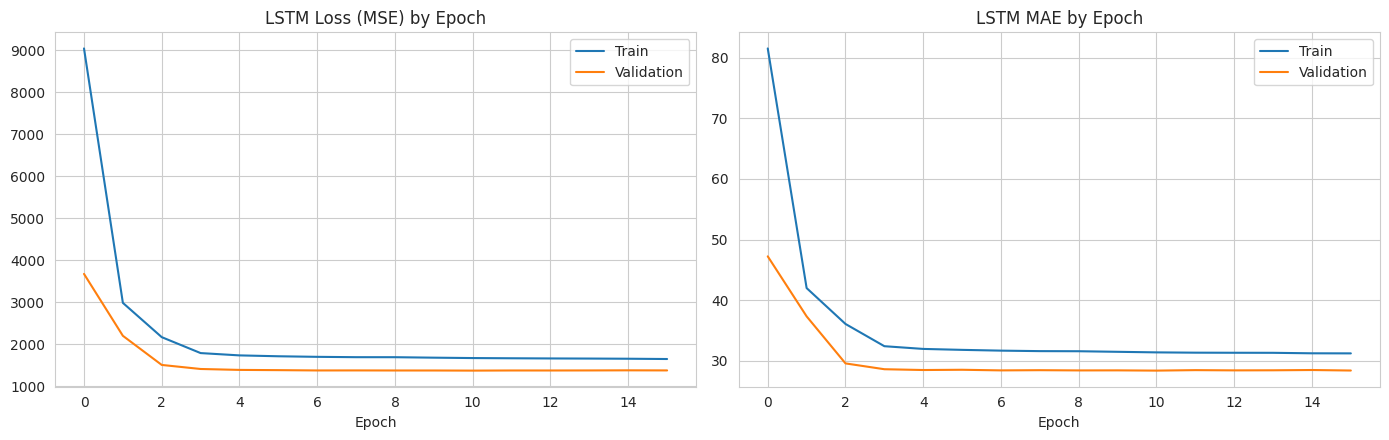

In [ ]:
# Training curves — checking for overfitting (train loss dropping while val loss rises)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('LSTM Loss (MSE) by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_title('LSTM MAE by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
lstm_preds = lstm_model.predict(X_seq_test_scaled, verbose=0).flatten()
print(f"LSTM predictions generated for {len(lstm_preds):,} test sequences")


LSTM predictions generated for 14,900 test sequences


## 8. Compare Model Performance

All four models are evaluated using the held-out future period.

Because `Demand` is continuous, the notebook uses:

- **MAE:** average absolute forecasting error; lower is better.
- **RMSE:** penalises larger errors more heavily; lower is better.
- **MAPE:** expresses error relative to actual demand; lower is better.
- **R²:** proportion of variation explained by the model; higher is better.

### Important note on MAPE

MAPE divides error by the actual demand. It can therefore become unstable when actual values are close to zero.

The minimum observed demand is **4 units**, so MAPE is useful as a percentage-based summary but should be interpreted together with MAE and RMSE.

### Evaluation fairness

The test period is **2023-09-04 to 2024-01-30**, containing **14,900 observations** for each model comparison.

The LSTM has a different input representation, but its test horizon is aligned to the same future period. This makes the comparison substantially more meaningful than evaluating each model on unrelated dates.

In [ ]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{name:>20} | MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | MAPE: {mape:6.2f}% | R2: {r2:.3f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'n_test': len(y_true)}

results = []
results.append(evaluate(y_test.values, lr_preds, 'Linear Regression'))
results.append(evaluate(y_test.values, rf_preds, 'Random Forest'))
results.append(evaluate(y_test.values, xgb_preds, 'XGBoost'))
results.append(evaluate(y_seq_test, lstm_preds, 'LSTM'))

results_df = pd.DataFrame(results).set_index('model')
results_df


   Linear Regression | MAE:   25.34 | RMSE:   32.68 | MAPE:  36.79% | R2: 0.453
       Random Forest | MAE:   22.48 | RMSE:   29.79 | MAPE:  32.84% | R2: 0.545
             XGBoost | MAE:   17.18 | RMSE:   23.35 | MAPE:  25.16% | R2: 0.721
                LSTM | MAE:   29.82 | RMSE:   38.35 | MAPE:  44.36% | R2: 0.247


,MAE,RMSE,MAPE,R2,n_test
model,,,,,
Linear Regression,25.340009,32.679648,36.793003,0.452978,14900
Random Forest,22.480390,29.793816,32.838681,0.545324,14900
XGBoost,17.183756,23.349771,25.160043,0.720736,14900
LSTM,29.817202,38.353545,44.364536,0.246538,14900


### Reading the model comparison

The observed test results are:

| Model | MAE | RMSE | MAPE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 25.34 | 32.68 | 36.79% | 0.453 |
| Random Forest | 22.48 | 29.79 | 32.84% | 0.545 |
| **XGBoost** | **17.18** | **23.35** | **25.16%** | **0.721** |
| LSTM | 29.82 | 38.35 | 44.36% | 0.247 |

### What the results mean

**XGBoost is the strongest model across every reported metric.**

Its MAE of **17.18** means the average absolute forecasting error is about 17 demand units. Its RMSE of **23.35** also indicates substantially smaller large-error behaviour than the other models.

The model achieves an **R² of 0.721**, meaning it explains approximately 72.1% of the variation in the held-out observations under this evaluation setup.

Random Forest is the second-best model, improving meaningfully over Linear Regression.

The LSTM is the weakest model in this experiment, with an MAE of **29.82** and R² of **0.247**.

### Why the LSTM may have underperformed

Several explanations are plausible:

1. **Strong engineered temporal features:** The tabular models receive explicit 1-day and 7-day lags plus rolling means. Much of the useful temporal structure has therefore already been exposed directly to XGBoost.
2. **Rich tabular representation:** The classical models receive one-hot encoded categorical information such as store and product identity.
3. **Limited observations per individual series:** Although the dataset contains 76,000 rows overall, the observations are distributed across 100 Store-Product series.
4. **Different feature representations:** The LSTM uses a curated 20-feature sequence representation, while the tabular models use the full encoded feature matrix. Therefore, this is not a perfectly controlled comparison of architecture alone.

The appropriate conclusion is not that LSTMs are inherently worse for demand forecasting.

> **For this dataset, feature set and evaluation period, XGBoost provides the best observed forecasting performance.**

The LSTM result is valuable because it demonstrates that increased model complexity does not automatically translate into better predictive performance.

### Figure 6 — Actual vs Predicted Demand

The actual-vs-predicted plots provide a visual equivalent of checking prediction quality across the full demand range.

The diagonal reference line represents perfect prediction.

A stronger model should place observations more tightly around this line and maintain reasonable accuracy across both low- and high-demand observations.

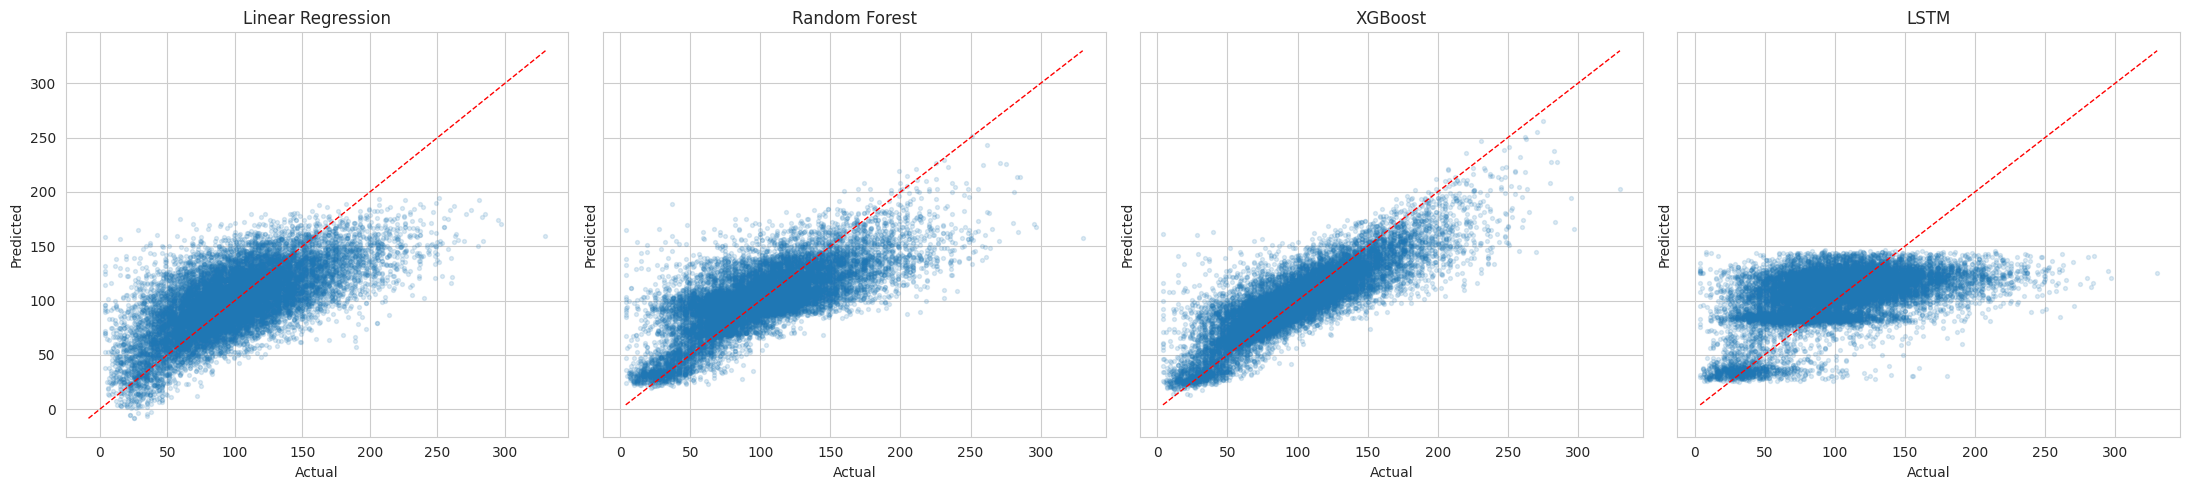

In [ ]:
# Actual vs Predicted -- the forecasting equivalent of a confusion matrix
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

preds_map = {
    'Linear Regression': (y_test.values, lr_preds),
    'Random Forest': (y_test.values, rf_preds),
    'XGBoost': (y_test.values, xgb_preds),
    'LSTM': (y_seq_test, lstm_preds),
}

for ax, (name, (y_true, y_pred)) in zip(axes, preds_map.items()):
    ax.scatter(y_true, y_pred, alpha=0.15, s=8)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()


### Figure 6 interpretation

The visual comparison complements the numerical metrics.

XGBoost should show the strongest concentration around the ideal diagonal, consistent with its substantially lower MAE/RMSE and higher R².

The plots are also useful for identifying systematic behaviour that a single metric may hide, such as underprediction at high demand or excessive spread around particular demand levels.

### Figure 7 — Residual Distribution by Model

A residual is calculated as:

**Residual = Actual Demand − Predicted Demand**

Therefore:

- Positive residual → the model underpredicted.
- Negative residual → the model overpredicted.
- Residual near zero → accurate prediction.

The residual distributions show how the models' errors are spread around zero.

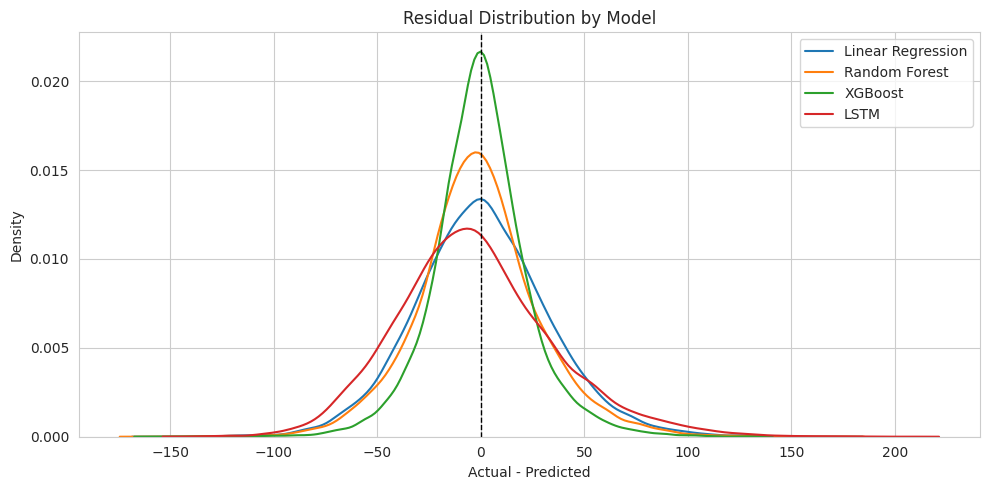

In [ ]:
# Residual distributions -- comparing error spread across all four models directly
fig, ax = plt.subplots(figsize=(10, 5))
for name, (y_true, y_pred) in preds_map.items():
    residuals = y_true - y_pred
    sns.kdeplot(residuals, label=name, ax=ax)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Residual Distribution by Model')
ax.set_xlabel('Actual - Predicted')
ax.legend()
plt.tight_layout()
plt.show()


### Figure 7 interpretation

A useful forecasting model should have residuals concentrated relatively close to zero without strong systematic bias.

The residual plot is important because MAE and RMSE describe average error magnitude, while residuals show the **shape and direction of the errors**.

Together, the metrics and residual distributions provide a more complete assessment of forecasting quality.

### Figure 8 — XGBoost Feature Importance

This graph shows the top 15 features used by XGBoost according to the model's built-in feature-importance measure.

Feature importance can help explain which variables the fitted tree model relies on most heavily.

> **Important:** Feature importance is not causal evidence. A highly important predictor means the model relies strongly on that variable; it does not prove that changing the variable will cause demand to change.

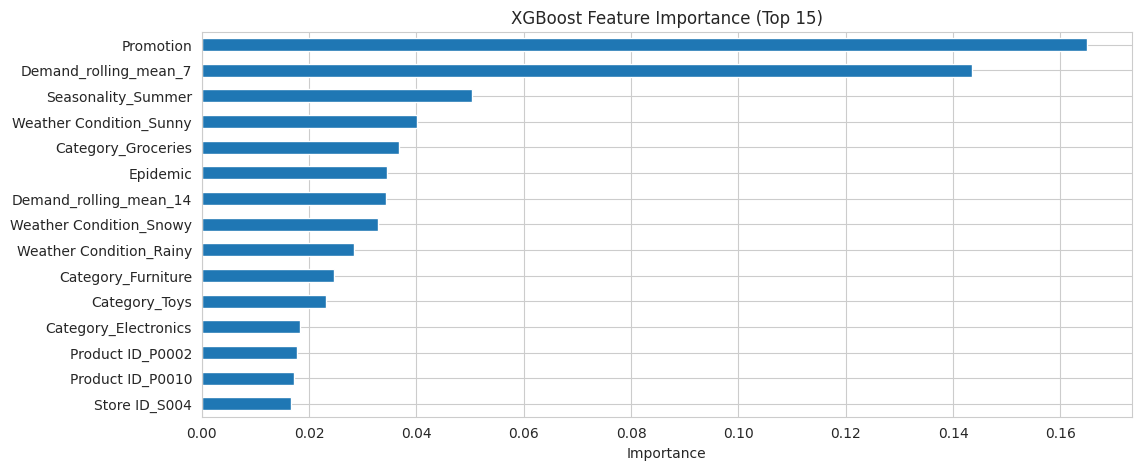

In [ ]:
# Feature importance (tree-based models) -- the LSTM has no equivalent single-feature
# importance in the same sense, since it learns temporal patterns across the whole window
# rather than weighting individual static features -- noted rather than papered over.
importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh')
plt.title('XGBoost Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()


### Figure 8 interpretation

The feature-importance analysis provides a bridge between model performance and model interpretation.

If historical demand lags and rolling statistics rank highly, this supports the conclusion that recent demand history contains substantial predictive information.

The results should nevertheless be interpreted as **model reliance**, not as a causal ranking of business drivers.

## 9. Final Findings & Business Recommendations

### Executive summary

This project developed an end-to-end demand forecasting workflow using a complete retail panel of **76,000 store-product-day observations**.

The data was validated as a complete panel with **100 Store-Product series and 760 observations per series**, enabling reliable historical feature construction.

Exploratory analysis showed meaningful variation across time, stores, categories and contextual conditions. These findings supported the use of calendar variables, lagged demand and operational history, as well as contextual commercial and environmental features.

Four models were then evaluated on a chronological future test period:

- Linear Regression
- Random Forest
- XGBoost
- LSTM

### Final model results

| Model | MAE | RMSE | MAPE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 25.34 | 32.68 | 36.79% | 0.453 |
| Random Forest | 22.48 | 29.79 | 32.84% | 0.545 |
| **XGBoost** | **17.18** | **23.35** | **25.16%** | **0.721** |
| LSTM | 29.82 | 38.35 | 44.36% | 0.247 |

### Final model selection

**XGBoost is selected as the preferred model for this dataset.**

It produces the lowest MAE, RMSE and MAPE and the highest R².

The result demonstrates that carefully engineered tabular features can outperform a recurrent deep-learning architecture when the underlying dataset is relatively structured and the available historical information can be represented effectively through lags and rolling statistics.

### Business applications

A demand forecasting model of this type could support:

- Inventory planning
- Replenishment scheduling
- Store/product demand monitoring
- Promotion planning
- Identifying unusually high or low expected demand
- Short-term operational planning

The forecast should be treated as **decision support**, not as an autonomous inventory decision. Business users would still need to consider supplier lead times, stock constraints, planned promotions, operational capacity and other information not represented in the dataset.

## Limitations

### 1. Same-day information assumptions

Same-day `Units Sold` and `Inventory Level` are deliberately excluded from the direct predictor set.

Other same-day contextual variables are retained under the assumption that they are known or forecastable at prediction time. In a production system, realised weather observations should ideally be replaced with weather forecasts available at forecast generation time.

### 2. LSTM comparison is not perfectly controlled

The tabular models receive the full encoded feature matrix, while the LSTM receives a curated sequence feature set.

A stronger future comparison could provide the LSTM with learned embeddings for Store ID and Product ID.

### 3. No traditional statistical forecasting baseline

The project does not include SARIMA, ETS or another dedicated classical time-series forecasting model.

Adding one would provide an additional benchmark against the machine-learning and deep-learning approaches.

### 4. MAPE sensitivity

MAPE can become unstable when actual demand is very small. MAE and RMSE should therefore remain important when interpreting model quality.

### 5. Limited external variables

The dataset does not contain potentially useful demand drivers such as holidays, local events, marketing spend or detailed supply-chain constraints.

### 6. Limited hyperparameter tuning

The models use fixed configurations rather than a large time-series hyperparameter search.

A production-quality implementation could use rolling/expanding-window validation to tune XGBoost and compare forecast performance across different horizons.

## Recommended next steps

1. Tune XGBoost using **time-aware cross-validation**.
2. Add **SARIMA/ETS** as statistical baselines.
3. Add learned **Store/Product embeddings** to the LSTM.
4. Incorporate holidays, events, marketing and richer weather forecasts where available.
5. Evaluate **1-day, 7-day and 14-day forecasting horizons**.
6. Report performance separately by **store, product and category**.
7. Add prediction intervals so that decision-makers can understand forecast uncertainty.
8. Build a Power BI dashboard showing forecast demand, actual demand, forecast error and high-risk inventory situations.

### Portfolio takeaway

The most important result is not simply that XGBoost achieved the highest score.

This notebook demonstrates the ability to:

- Validate a panel time-series dataset
- Identify and control forecasting leakage
- Engineer historical and calendar features
- Preserve chronological ordering
- Compare classical machine learning with deep learning
- Evaluate forecasts using multiple regression metrics
- Diagnose errors visually
- Interpret model behaviour
- Explain why a complex model can underperform a simpler alternative
- Translate predictive modelling into practical business applications

That combination of **technical modelling, methodological awareness and business interpretation** is the main value of this project as a portfolio piece.